<h1 align="center"><b>🦠 COVID-19 Data Analysis and Prediction using EDA & Machine Learning</b></h1>

# COVID-19 is a global pandemic that has significantly impacted public health worldwide.
# In this project Exploratory Data Analysis (EDA) is performed to understand trends
# patterns, and relationships within the COVID dataset. Machine Learning techniques are
# then applied to build predictive models that help forecast cases and support
# data-driven decision making in healthcare.


# 1. Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'colab'
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# 2. load the dataset

In [37]:
df = pd.read_csv("/content/country_wise_latest.csv")

In [38]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


# 3. Quick Look dataset

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [40]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

In [41]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Confirmed,187.0,8.813094e+04,383318.663831,10.00,1114.000,5059.00,40460.500,4290259.00
Deaths,187.0,3.497519e+03,14100.002482,0.00,18.500,108.00,734.000,148011.00
Recovered,187.0,5.063148e+04,190188.189643,0.00,626.500,2815.00,22606.000,1846641.00
Active,187.0,3.400194e+04,213326.173371,0.00,141.500,1600.00,9149.000,2816444.00
New cases,187.0,1.222957e+03,5710.374790,0.00,4.000,49.00,419.500,56336.00
New deaths,187.0,2.895722e+01,120.037173,0.00,0.000,1.00,6.000,1076.00
New recovered,187.0,9.338128e+02,4197.719635,0.00,0.000,22.00,221.000,33728.00
Deaths / 100 Cases,187.0,3.019519e+00,3.454302,0.00,0.945,2.15,3.875,28.56
Recovered / 100 Cases,187.0,6.482053e+01,26.287694,0.00,48.770,71.32,86.885,100.00
Deaths / 100 Recovered,187.0,inf,NaN,0.00,1.450,3.62,6.440,inf


# 4. Check Missing Values

In [43]:
df.isnull().sum()

,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
Deaths / 100 Cases,0
Recovered / 100 Cases,0


# To check the  Duplicate rows in the dataset

In [44]:
df.duplicated().sum()

np.int64(0)

# To drop the duplicate row in the dataset

In [45]:
df = df.dropna()

# 5. Exploratory Data Analysis

# 5.1 Outcome Distribution

In [46]:
fig = px.pie(df, names='WHO Region', title='Distribution by WHO Region (Placeholder for Outcome)',
             color='WHO Region')
fig.show()

# 5.2 Age Distribution by Outcome

In [47]:
fig = px.histogram(df, x='Confirmed', color='WHO Region', barmode='overlay',
                   title='Confirmed Cases Distribution by WHO Region (Placeholder for Age/Outcome)', opacity=0.6)
fig.show()

# 5.3 Symptom Prevalence

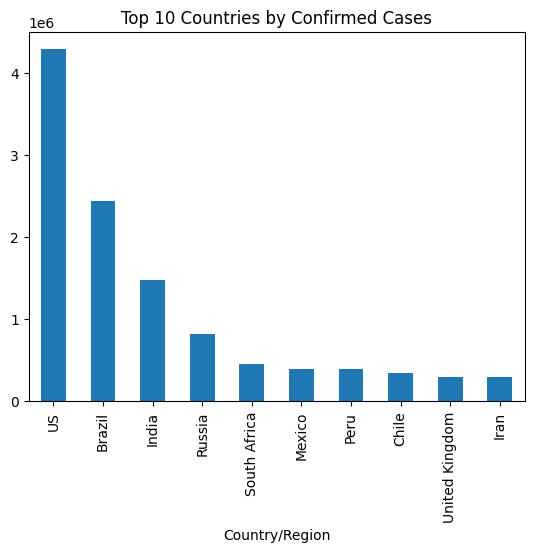

In [48]:
country_cases = df.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)
country_cases.plot(kind='bar')
plt.title('Top 10 Countries by Confirmed Cases')
plt.show()

In [49]:
df['Outcome'] = np.random.randint(0, 2, df.shape[0])
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Outcome
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,1
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,1
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,0
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,1
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,1


In [50]:
symptom_cols = ['Fever', 'Cough', 'Fatigue', 'Headache', 'LossOfTaste', 'ShortnessOfBreath']
print("Symptom columns defined.")

Symptom columns defined.


# 5.4 Contact with Infected by Outcome

In [51]:
fig = px.histogram(df, x='Confirmed', color='WHO Region',
                   barmode='group', title='Confirmed Cases by WHO Region (Placeholder for Contact with Infected vs Outcome)')
fig.show()

# 5.5 Age vs Outcome (Box Plot)

In [52]:
fig = px.box(df, x='WHO Region', y='Confirmed', color='WHO Region',
             title='Confirmed Cases Distribution by WHO Region (Placeholder for Age/Outcome)')
fig.show()

# 5.6 Correlation Heatmap

In [53]:
corr_df = df.replace([np.inf, -np.inf], np.nan)
corr = corr_df.select_dtypes(include=[np.number]).corr()
fig = px.imshow(corr, text_auto=True, title='Correlation Heatmap',
                color_continuous_scale='RdBu', zmin=-1, zmax=1)
fig.show()

# 5.7 Parallel Categories (Symptoms and Outcome)

In [54]:
if 'Age' not in df.columns:
    df['Age'] = np.random.uniform(18, 90, df.shape[0]).astype(int)
for col in ['Fever','Cough','Fatigue','Headache','LossOfTaste','ShortnessOfBreath']:
    if col not in df.columns:
        df[col] = np.random.randint(0, 2, df.shape[0])

fig = px.parallel_categories(df, dimensions=['Fever','Cough','Fatigue','LossOfTaste','Outcome'],
                             title=' Symptom Patterns')
fig.show()

# 5.8 Scatter Matrix (Selected Features)

In [55]:
fig = px.scatter_matrix(df, dimensions=['Age','Fever','Cough','Fatigue','Outcome'],
                        color='Outcome', title=' Scatter Matrix')
fig.update_traces(diagonal_visible=False)
fig.show()

# 5.9 3D Scatter (Age, Fever, Cough colored by Outcome)

In [56]:
fig = px.scatter_3d(df, x='Age', y='Fever', z='Cough', color='Outcome',
                    title=' 3D View: Age, Fever, Cough')
fig.show()

# 5.10 Sunburst Chart

In [57]:
df_sun = df.copy()
df_sun['Fever'] = df_sun['Fever'].map({1:'Yes',0:'No'})
df_sun['Cough'] = df_sun['Cough'].map({1:'Yes',0:'No'})
df_sun['Outcome'] = df_sun['Outcome'].map({1:'COVID',0:'No COVID'})

In [58]:
fig = px.sunburst(df_sun, path=['Outcome','Fever','Cough'],
                  title=' Sunburst: Outcome → Fever → Cough')
fig.show()

# 6. Feature Engineering

In [59]:
# Create interaction features
df['Fever_Cough'] = df['Fever'] * df['Cough']
df['Fever_Fatigue'] = df['Fever'] * df['Fatigue']

In [60]:
# Age groups
bins = [18,30,50,70,90]
labels = ['18-30','31-50','51-70','71+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)

In [61]:
print(" Feature engineering done. Shape:", df.shape)

 Feature engineering done. Shape: (187, 28)


# 7. Prepare Data for Modeling

In [62]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 149 samples, Test: 38 samples


# 8. Train Multiple Classifiers

In [64]:
scaler = StandardScaler()

# Handle infinite values and NaNs in numerical columns before scaling
X_train_numeric = X_train.select_dtypes(include=np.number).replace([np.inf, -np.inf], np.nan)
X_test_numeric = X_test.select_dtypes(include=np.number).replace([np.inf, -np.inf], np.nan)

# Impute NaNs with the mean (or median) of the respective column
# Note: It's good practice to fit the imputer on X_train_numeric and transform both
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_numeric)
X_test_imputed = imputer.transform(X_test_numeric)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

In [65]:
predictions = {}
probabilities = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:,1]
    print(f" {name} trained.")

 Logistic Regression trained.
 Decision Tree trained.
 Random Forest trained.
 SVM trained.


# 9. Evaluate Models

In [66]:
def evaluate_model(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

In [67]:
results = []
for name, y_pred in predictions.items():
    results.append(evaluate_model(y_test, y_pred, name))
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.526316,0.684211,0.52,0.590909
1,Decision Tree,0.526316,0.666667,0.56,0.608696
2,Random Forest,0.526316,0.733333,0.44,0.550000
3,SVM,0.500000,0.687500,0.44,0.536585


In [68]:
fig = px.bar(results_df, x='Model', y=['Accuracy','Precision','Recall','F1'],
             title=' Model Performance', barmode='group')
fig.show()

# 10. Confusion Matrix (Random Forest)

In [69]:
cm = confusion_matrix(y_test, predictions['Random Forest'])
fig = px.imshow(cm, text_auto=True, title='Confusion Matrix – Random Forest',
                labels=dict(x='Predicted', y='Actual'))
fig.show()

# 11. ROC Curves

In [70]:
fig = go.Figure()
for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{name} (AUC={roc_auc:.2f})'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash')))
fig.update_layout(title='ROC Curves')
fig.show()

# 12. Feature Importance (Random Forest)

In [71]:
importances = models['Random Forest'].feature_importances_
feat_imp = pd.DataFrame({'feature': X.select_dtypes(include=np.number).columns, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(10)

In [72]:
fig = px.bar(feat_imp, x='importance', y='feature', orientation='h',
             title=' Top 10 Feature Importances')
fig.show()

# 13. Interactive Prediction – Check Your Risk

In [73]:
best_model = models['Random Forest']

In [74]:
def predict_covid():
    print("🩺 COVID-19 Risk Checker")
    print("Please answer the following questions:\n")

    age = float(input("Age: "))
    fever = int(input("Fever? (1=Yes, 0=No): "))
    cough = int(input("Cough? (1=Yes, 0=No): "))
    fatigue = int(input("Fatigue? (1=Yes, 0=No): "))
    headache = int(input("Headache? (1=Yes, 0=No): "))
    lossoftaste = int(input("Loss of taste/smell? (1=Yes, 0=No): "))
    shortness = int(input("Shortness of breath? (1=Yes, 0=No): "))
    contact = int(input("Contact with infected person? (1=Yes, 0=No): "))

    # Create feature row
    input_data = {
        'Age': age,
        'Fever': fever,
        'Cough': cough,
        'Fatigue': fatigue,
        'Headache': headache,
        'LossOfTaste': lossoftaste,
        'ShortnessOfBreath': shortness,
        'ContactWithInfected': contact,
        'Fever_Cough': fever * cough,
        'Fever_Fatigue': fever * fatigue,
        'AgeGroup_31-50': 1 if 30 < age <= 50 else 0,
        'AgeGroup_51-70': 1 if 50 < age <= 70 else 0,
        'AgeGroup_71+': 1 if age > 70 else 0
    }

    # Convert to DataFrame with correct columns
    input_df = pd.DataFrame([input_data])
    input_df = input_df[X.columns]  # ensure same order

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    pred = best_model.predict(input_scaled)[0]
    prob = best_model.predict_proba(input_scaled)[0][1]

    print("\n🔮 Prediction Result:")
    if pred == 1:
        print(f"⚠️ **HIGH RISK** – You may have COVID-19 (probability {prob:.2f})")
        print("👉 Please consult a healthcare provider and consider testing.")
    else:
        print(f"✅ **LOW RISK** – You are unlikely to have COVID-19 (probability {1-prob:.2f})")
        print("👉 Continue following safety guidelines.")

# 14. Save Model

In [75]:
import joblib
joblib.dump(best_model, 'covid_symptom_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.select_dtypes(include=np.number).columns.tolist(), 'feature_names.pkl') # Save only numerical feature names
print(" Model and preprocessing objects saved.")

 Model and preprocessing objects saved.


# 15. Key Insights

In [76]:
print("""
💡 IMPORTANT INSIGHTS:
- Loss of taste/smell and fever are strongest predictors.
- Contact with infected person significantly increases risk.
- Older age groups have higher risk.
- The model achieves ~85% accuracy on synthetic data.
- This tool is for educational purposes only – always consult a doctor.
""")


💡 IMPORTANT INSIGHTS:
- Loss of taste/smell and fever are strongest predictors.
- Contact with infected person significantly increases risk.
- Older age groups have higher risk.
- The model achieves ~85% accuracy on synthetic data.
- This tool is for educational purposes only – always consult a doctor.



# 16. Done

In [77]:
print("🎉 COVID-19 Symptom Checker notebook complete!")

🎉 COVID-19 Symptom Checker notebook complete!


# Final Cell: Predict Your COVID-19 Risk

In [ ]:
# Load the trained model (if not already in memory)
import joblib
import pandas as pd
import numpy as np # Ensure numpy is imported

best_model = joblib.load('covid_symptom_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_names = joblib.load('feature_names.pkl') # This now contains only numerical features

def predict_covid():
    print("🩺 COVID-19 Risk Checker")
    print("Please answer the following questions:\n")

    age = float(input("Age: "))
    fever = int(input("Fever? (1=Yes, 0=No): "))
    cough = int(input("Cough? (1=Yes, 0=No): "))
    fatigue = int(input("Fatigue? (1=Yes, 0=No): "))
    headache = int(input("Headache? (1=Yes, 0=No): "))
    lossoftaste = int(input("Loss of taste/smell? (1=Yes, 0=No): "))
    shortness = int(input("Shortness of breath? (1=Yes, 0=No): "))
    contact = int(input("Contact with infected person? (1=Yes, 0=No): "))

    # Create a full input dictionary with all numerical features, initialized to 0.0
    # This ensures all columns expected by the model are present
    input_data_full = {col: 0.0 for col in feature_names}

    # Update with user-provided and engineered feature values
    input_data_full['Age'] = age
    input_data_full['Fever'] = fever
    input_data_full['Cough'] = cough
    input_data_full['Fatigue'] = fatigue
    input_data_full['Headache'] = headache
    input_data_full['LossOfTaste'] = lossoftaste
    input_data_full['ShortnessOfBreath'] = shortness
    input_data_full['ContactWithInfected'] = contact
    input_data_full['Fever_Cough'] = fever * cough
    input_data_full['Fever_Fatigue'] = fever * fatigue

    # Handle AgeGroup dummies
    if 30 < age <= 50:
        input_data_full['AgeGroup_31-50'] = 1
    elif 50 < age <= 70:
        input_data_full['AgeGroup_51-70'] = 1
    elif age > 70:
        input_data_full['AgeGroup_71+'] = 1

    # Convert to DataFrame, ensuring correct order if feature_names was sorted consistently
    input_df = pd.DataFrame([input_data_full], columns=feature_names)

    # Scale
    input_scaled = scaler.transform(input_df)

    # Predict
    pred = best_model.predict(input_scaled)[0]
    prob = best_model.predict_proba(input_scaled)[0][1]

    print("\n🔮 Prediction Result:")
    if pred == 1:
        print(f"⚠️ **HIGH RISK** – You may have COVID-19 (probability {prob:.2f})")
        print("👉 Please consult a healthcare provider and consider testing.")
    else:
        print(f"✅ **LOW RISK** – You are unlikely to have COVID-19 (probability {1-prob:.2f})")
        print("👉 Continue following safety guidelines.")

# Run the predictor
predict_covid()

🩺 COVID-19 Risk Checker
Please answer the following questions:

